In [36]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
conn = sqlite3.connect('../database/students.db')
df = pd.read_sql("SELECT * FROM cleaned_data", conn)
conn.close()

# Remove the one data entry error (score > 100)
df = df[df['Exam_Score'] <= 100]

# One-hot encode categoricals, drop first to avoid dummy variable trap
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

print(f"Dataset shape: {df_encoded.shape}")
print(f"Features: {X.shape[1]}, Target: Exam_Score")

Dataset shape: (6377, 28)
Features: 27, Target: Exam_Score


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=91666719
)

# Convert booleans to float for statsmodels compatibility
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

Train size: 5101 rows
Test size:  1276 rows


In [39]:
# Check Multicollinearity with VIF
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

# Drop features with VIF > 10
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nDropping high VIF features: {high_vif}")

X_train_clean = X_train.drop(columns=high_vif)
X_test_clean = X_test.drop(columns=high_vif)

                                  Feature        VIF
1                              Attendance  34.548232
3                         Previous_Scores  23.586249
2                             Sleep_Hours  20.542316
13                    Internet_Access_Yes  12.467705
0                           Hours_Studied  11.531418
5                       Physical_Activity   8.915918
25                Distance_from_Home_Near   6.652416
24            Distance_from_Home_Moderate   3.900087
12                Motivation_Level_Medium   3.417379
18                     School_Type_Public   3.224201
14                      Family_Income_Low   3.043973
15                   Family_Income_Medium   3.018042
17                 Teacher_Quality_Medium   2.972599
20                Peer_Influence_Positive   2.858511
19                 Peer_Influence_Neutral   2.830349
7             Parental_Involvement_Medium   2.748471
9              Access_to_Resources_Medium   2.683189
22   Parental_Education_Level_High School   2.

In [40]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
            'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])  # same scaler, no leakage

In [41]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_scaled.values, i)
                   for i in range(X_train_scaled.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data.to_string())

# Drop features with VIF > 10
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nDropping high VIF features: {high_vif}")

X_train_clean = X_train_scaled.drop(columns=high_vif)
X_test_clean  = X_test_scaled.drop(columns=high_vif)

                                  Feature        VIF
13                    Internet_Access_Yes  10.059925
25                Distance_from_Home_Near   5.719732
24            Distance_from_Home_Moderate   3.427120
12                Motivation_Level_Medium   3.228934
18                     School_Type_Public   3.116468
17                 Teacher_Quality_Medium   2.872054
14                      Family_Income_Low   2.853596
15                   Family_Income_Medium   2.849485
20                Peer_Influence_Positive   2.722442
19                 Peer_Influence_Neutral   2.694851
7             Parental_Involvement_Medium   2.653361
9              Access_to_Resources_Medium   2.607630
22   Parental_Education_Level_High School   2.546848
10         Extracurricular_Activities_Yes   2.383991
26                            Gender_Male   2.343312
11                   Motivation_Level_Low   2.242123
6                Parental_Involvement_Low   1.643300
23  Parental_Education_Level_Postgraduate   1.

In [42]:
def backward_selection(X, y, threshold=0.05):
    features = list(X.columns)
    while True:
        X_with_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_const).fit()
        pvalues = model.pvalues.drop('const')
        max_pval = pvalues.max()
        if max_pval > threshold:
            worst = pvalues.idxmax()
            print(f"Removing '{worst}' (p={max_pval:.4f})")
            features.remove(worst)
        else:
            break
    return features, model

In [43]:
print("=" * 50)
print("MODEL 1 — Full Training Set")
print("=" * 50)

selected_features, final_model = backward_selection(X_train_clean, y_train)
print(f"\nSelected {len(selected_features)} features: {selected_features}")
print(final_model.summary())

MODEL 1 — Full Training Set
Removing 'Sleep_Hours' (p=0.7881)
Removing 'Gender_Male' (p=0.7605)
Removing 'School_Type_Public' (p=0.2409)

Selected 23 features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  

In [44]:
X_test_final = sm.add_constant(X_test_clean[selected_features])
y_pred = final_model.predict(X_test_final)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2   = r2_score(y_test, y_pred)

print("MODEL 1 — Test Set Performance")
print(f"  Test RMSE:       {test_rmse:.2f}")
print(f"  Test R²:         {test_r2:.4f}")
print(f"  Train Adj. R²:   {final_model.rsquared_adj:.4f}")
print(f"  Train-Test Gap:  {final_model.rsquared_adj - test_r2:.4f}")

MODEL 1 — Test Set Performance
  Test RMSE:       2.19
  Test R²:         0.6878
  Train Adj. R²:   0.7283
  Train-Test Gap:  0.0406


In [45]:
print("=" * 50)
print("MODEL 2 — Outliers Removed (residual > 10)")
print("=" * 50)

# Identify and remove outliers from training set only
residuals_m1 = y_train - final_model.fittedvalues
outlier_mask = residuals_m1 > 10

X_train_no_outliers = X_train_clean[~outlier_mask.values]
y_train_no_outliers = y_train[~outlier_mask.values]
print(f"Removed {outlier_mask.sum()} outliers — {len(X_train_no_outliers)} rows remaining")

selected_features2, final_model2 = backward_selection(X_train_no_outliers, y_train_no_outliers)
print(f"\nSelected {len(selected_features2)} features")
print(final_model2.summary())

MODEL 2 — Outliers Removed (residual > 10)
Removed 38 outliers — 5063 rows remaining
Removing 'Gender_Male' (p=0.9616)
Removing 'School_Type_Public' (p=0.2952)

Selected 24 features
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                 1.382e+04
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:54:54   Log-Likelihood:                -2667.5
No. Observations:                5063   AIC:                             5385.
Df Residuals:                    5038   BIC:                             5548.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                            

In [46]:
X_test_final2 = sm.add_constant(X_test_clean[selected_features2])
y_pred2 = final_model2.predict(X_test_final2)

test_rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
test_r2_2  = r2_score(y_test, y_pred2)

print("MODEL 2 — Test Set Performance")
print(f"  Test RMSE:       {test_rmse2:.2f}")
print(f"  Test R²:         {test_r2_2:.4f}")
print(f"  Train Adj. R²:   {final_model2.rsquared_adj:.4f}")
print(f"  Train-Test Gap:  {final_model2.rsquared_adj - test_r2_2:.4f}")

print("\n--- Model Comparison ---")
print(f"{'Metric':<20} {'Model 1':>10} {'Model 2':>10}")
print(f"{'Train Adj. R²':<20} {final_model.rsquared_adj:>10.4f} {final_model2.rsquared_adj:>10.4f}")
print(f"{'Test R²':<20} {test_r2:>10.4f} {test_r2_2:>10.4f}")
print(f"{'Test RMSE':<20} {test_rmse:>10.2f} {test_rmse2:>10.2f}")
print(f"{'Train-Test Gap':<20} {final_model.rsquared_adj - test_r2:>10.4f} {final_model2.rsquared_adj - test_r2_2:>10.4f}")
print(f"\nSelected Model: Model 1 (better generalization, gap={final_model.rsquared_adj - test_r2:.4f})")

MODEL 2 — Test Set Performance
  Test RMSE:       2.20
  Test R²:         0.6867
  Train Adj. R²:   0.9850
  Train-Test Gap:  0.2983

--- Model Comparison ---
Metric                  Model 1    Model 2
Train Adj. R²            0.7283     0.9850
Test R²                  0.6878     0.6867
Test RMSE                  2.19       2.20
Train-Test Gap           0.0406     0.2983

Selected Model: Model 1 (better generalization, gap=0.0406)


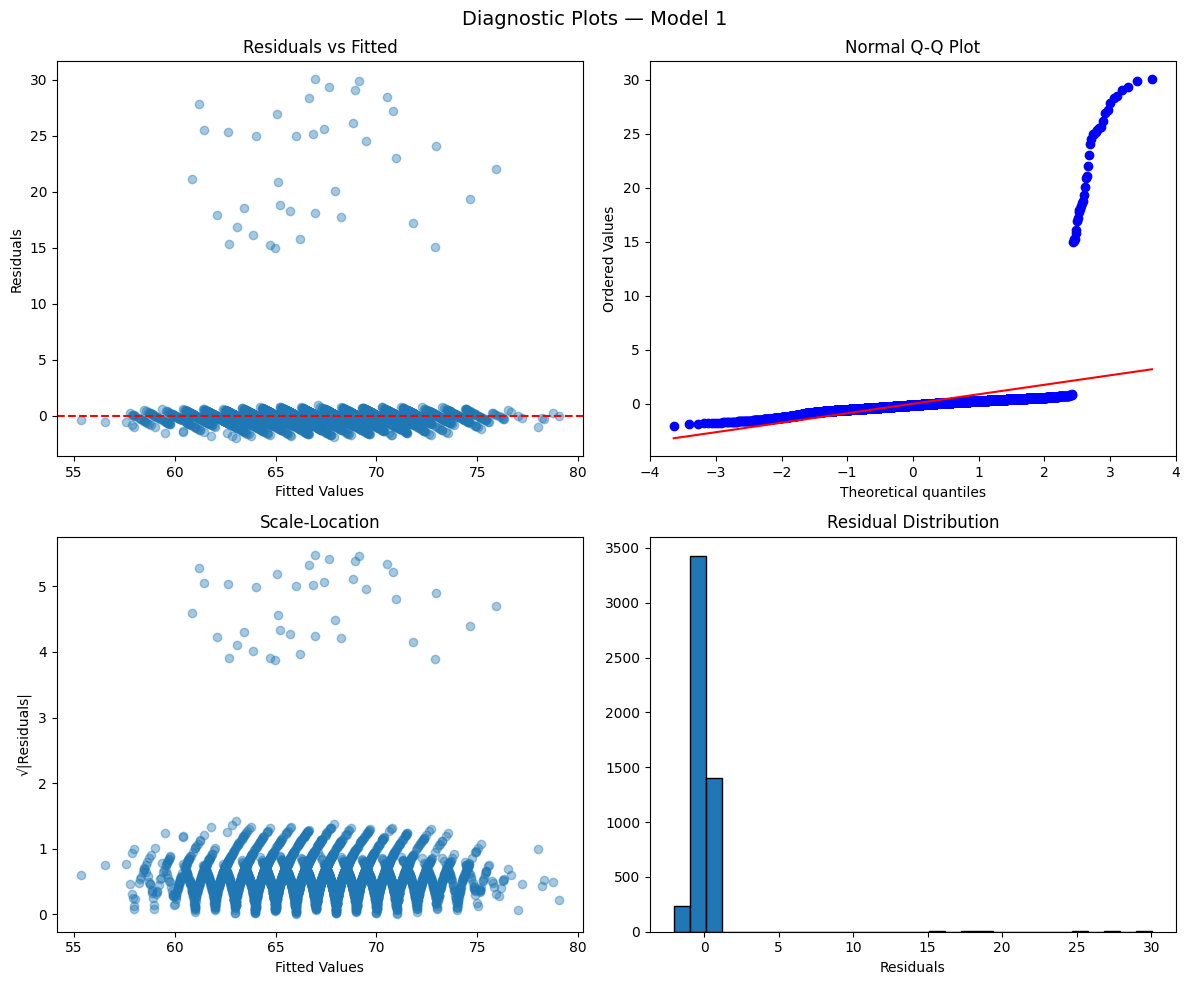

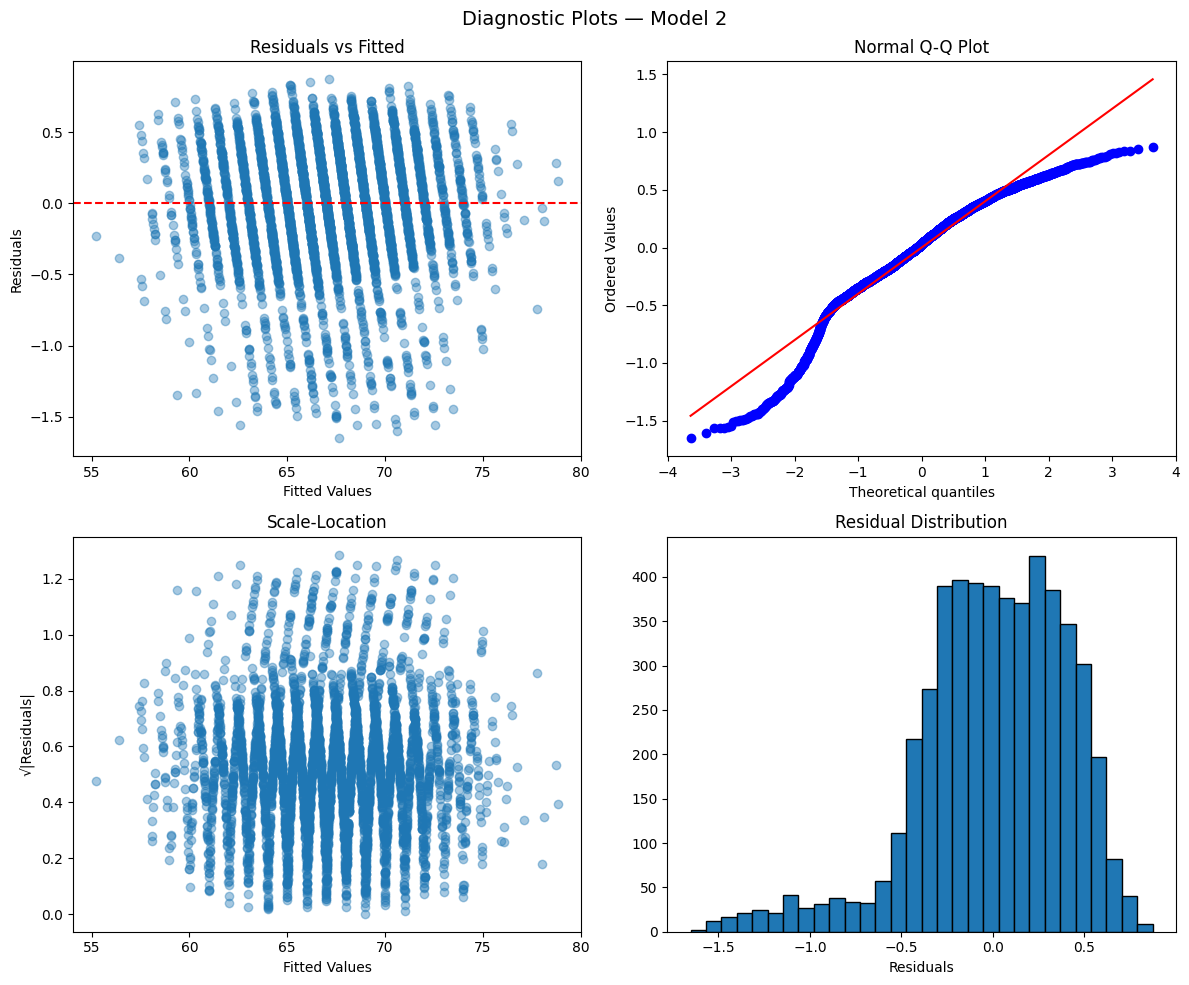

In [47]:
os.makedirs('../report/figures', exist_ok=True)

for label, model, y_tr in [("Model 1", final_model, y_train),
                             ("Model 2", final_model2, y_train_no_outliers)]:
    res = y_tr - model.fittedvalues
    fit = model.fittedvalues

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Diagnostic Plots — {label}', fontsize=14)

    axes[0,0].scatter(fit, res, alpha=0.4)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set(title='Residuals vs Fitted', xlabel='Fitted Values', ylabel='Residuals')

    stats.probplot(res, plot=axes[0,1])
    axes[0,1].set_title('Normal Q-Q Plot')

    axes[1,0].scatter(fit, np.sqrt(np.abs(res)), alpha=0.4)
    axes[1,0].set(title='Scale-Location', xlabel='Fitted Values', ylabel='√|Residuals|')

    axes[1,1].hist(res, bins=30, edgecolor='black')
    axes[1,1].set(title='Residual Distribution', xlabel='Residuals')

    plt.tight_layout()
    fname = label.lower().replace(" ", "_")
    plt.savefig(f'../report/figures/diagnostic_plots_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

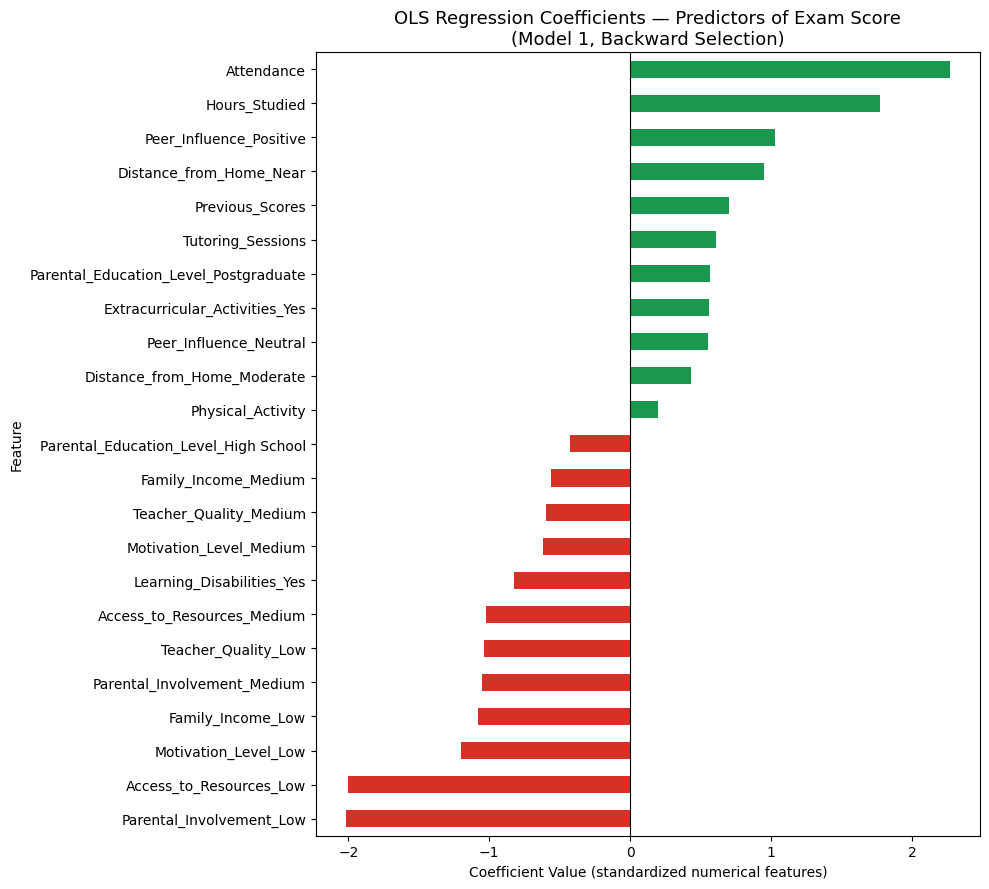


Top 5 positive predictors:
Attendance                 2.269243
Hours_Studied              1.772800
Peer_Influence_Positive    1.028451
Distance_from_Home_Near    0.950062
Previous_Scores            0.701733
dtype: float64

Top 5 negative predictors:
Parental_Involvement_Low      -2.017086
Access_to_Resources_Low       -2.002609
Motivation_Level_Low          -1.200142
Family_Income_Low             -1.080707
Parental_Involvement_Medium   -1.051718
dtype: float64


In [48]:
coef = final_model.params.drop('const').sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#d73027' if v < 0 else '#1a9850' for v in coef]
coef.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('OLS Regression Coefficients — Predictors of Exam Score\n(Model 1, Backward Selection)', fontsize=13)
ax.set_xlabel('Coefficient Value (standardized numerical features)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../report/figures/coefficients_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 positive predictors:")
print(final_model.params.drop('const').sort_values(ascending=False).head(5))
print("\nTop 5 negative predictors:")
print(final_model.params.drop('const').sort_values().head(5))